In [94]:
!pip install pyts

   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   - -------------------------------------- 0.1/2.5 MB 3.3 MB/s eta 0:00:01
   ---- ----------------------------------- 0.3/2.5 MB 3.1 MB/s eta 0:00:01
   ------ --------------------------------- 0.4/2.5 MB 3.4 MB/s eta 0:00:01
   ------------ --------------------------- 0.8/2.5 MB 4.3 MB/s eta 0:00:01
   -------------- ------------------------- 1.0/2.5 MB 4.3 MB/s eta 0:00:01
   ------------------- -------------------- 1.3/2.5 MB 4.5 MB/s eta 0:00:01
   ------------------------- -------------- 1.6/2.5 MB 4.8 MB/s eta 0:00:01
   ----------------------------- ---------- 1.9/2.5 MB 5.2 MB/s eta 0:00:01
   ---------------------------------- ----- 2.2/2.5 MB 5.4 MB/s eta 0:00:01
   ---------------------------------------  2.5/2.5 MB 5.4 MB/s eta 0:00:01
   ---------------------------------------- 2.5/2.5 MB 5.2 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   -- --------------------


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\lenovo\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pyts.image import RecurrencePlot

In [2]:
df = pd.read_csv("E:/CoDaS Project/archive/Radar/C3/radar_merged_data.csv")

In [3]:
df.head()

,timestamp,user_id,emotion,x_0,y_0,z_0,x_1,y_1,z_1,x_2,...,z_9,x_10,y_10,z_10,x_11,y_11,z_11,x_12,y_12,z_12
0,0.000000,U03,E01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,1.267099,-1.267099,2.239453,NaN,NaN,NaN,NaN,NaN,NaN
1,0.065292,U03,E01,NaN,NaN,NaN,NaN,NaN,NaN,-0.626953,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.088774,U03,E01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.098769,U03,E01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.098769,U03,E01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
for group_name, group_data in df.groupby(["user_id","emotion"]):
    print(f"User ID: {group_name[0]}, Emotion: {group_name[1]}, Number of Samples: {len(group_data)}")
    break

User ID: U03, Emotion: E01, Number of Samples: 4187


In [5]:
time_length = 6
time = np.round(group_data["timestamp"].to_numpy(),decimals=2)

In [6]:
time_length = 6
cursor= min(time) # Starting point
segments = []  # To store the segmented data
while True:
    # Process the current portion
    positions=np.where((time >= cursor) & (time <= cursor + time_length))[0]
    segments.append((positions[0], positions[-1]))
    if cursor + time_length >= max(time) or len(positions) == 0:
        break
    cursor = time[positions[-1]+1]  # Move cursor to the next segment
    
print(segments)

[(0, 471), (472, 742), (743, 1159), (1160, 1487), (1488, 1913), (1914, 2213), (2214, 2553), (2554, 2781), (2782, 2880), (2881, 3014), (3015, 3316), (3317, 3449), (3450, 3516), (3517, 3558), (3559, 3682), (3683, 3793), (3794, 3930), (3931, 4019), (4020, 4083), (4084, 4186)]


In [7]:
data_segment=group_data.iloc[segments[0][0]:segments[0][1]+1]

In [15]:
sensor_segment=data_segment[["timestamp","x_0","y_0","z_0"]].dropna()

In [28]:
signal=sensor_segment.to_numpy()[:,1].reshape(1, -1)

Text(0, 0.5, 'Time')

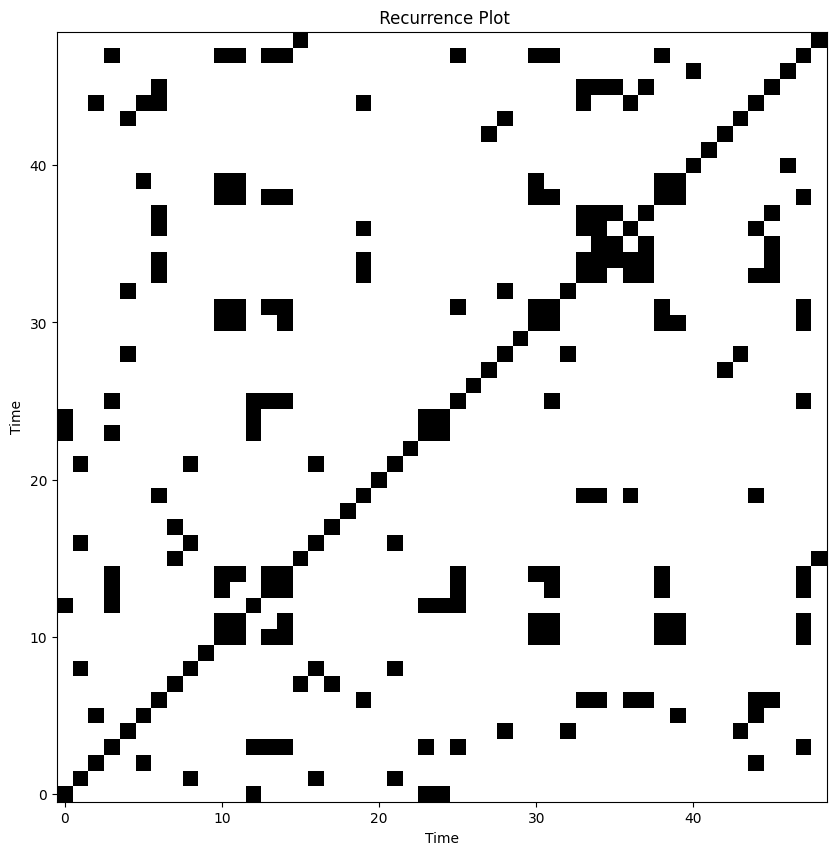

In [31]:
rp = RecurrencePlot(threshold='point', percentage=10)

fig, axs = plt.subplots(1, 1, figsize=(12, 10))
# Compute and plot recurrence plot
rp_image = rp.fit_transform(signal)[0]
axs.imshow(rp_image, cmap='binary', origin='lower')
axs.set_title(f' Recurrence Plot')
axs.set_xlabel('Time')
axs.set_ylabel('Time')